<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Speciale_kode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speciale

## Baseline

Fordelingen af data

For-rerec

Training
Real:5104
Fake:5104

Validation
Real:1101
Fake:1143

Test:
Real:408
Fake:408

###Download the data from Google Drev


Connects Google Colab to Google Drive so the dataset stored in Drive can be accessed

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the main folder path where the dataset is stored in Google Drive

In [30]:
base_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"

Check the dataset structure

In [31]:
import os

os.listdir("/content/drive/MyDrive/Speciale/for-rerecorded 2")

['testing', 'training', 'validation']

Define paths for each dataset split

In [32]:
train_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2/training"
val_path   = "/content/drive/MyDrive/Speciale/for-rerecorded 2/validation"
test_path  = "/content/drive/MyDrive/Speciale/for-rerecorded 2/testing"

Count files in each folder

In [33]:
import os
import pandas as pd

data = []

for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        path = f"/content/drive/MyDrive/Speciale/for-rerecorded 2/{split}/{label}"
        count = len(os.listdir(path))
        data.append([split, label, count])

df = pd.DataFrame(data, columns=["Dataset", "Class", "Count"])
df

,Dataset,Class,Count
0,training,real,5104
1,training,fake,5104
2,validation,real,1101
3,validation,fake,1143
4,testing,real,408
5,testing,fake,408


###Create Mel spectogrammer

Lav Mel spectogram på første 5 real og fake i train, for at se hvordan det ser ud

In [34]:
!pip install librosa

In [35]:
!cp -r "/content/drive/MyDrive/Speciale/for-rerecorded 2" /content/for-rerec

In [37]:
!ls "/content/for-rerec/for-rerecorded 2"

testing  training  validation


In [43]:
import os
import numpy as np
import librosa

base_path = "/content/for-rerec/for-rerecorded 2"

def get_all_wav_paths(split, label):
    folder = os.path.join(base_path, split, label)
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")]
    files.sort()
    return files


# -------- TRAIN --------

train_real = get_all_wav_paths("training", "real")
train_fake = get_all_wav_paths("training", "fake")

# -------- VALIDATION --------

val_real = get_all_wav_paths("validation", "real")
val_fake = get_all_wav_paths("validation", "fake")

# -------- TEST --------

test_real = get_all_wav_paths("testing", "real")
test_fake = get_all_wav_paths("testing", "fake")


def create_mel_spectrogram(file_path, sr=16000, n_mels=128, duration=2.0):

    # Load only the first 2 seconds
    audio, _ = librosa.load(file_path, sr=sr, duration=duration)

    # Pad if shorter than 2 seconds
    target_len = int(sr * duration)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    # Create mel spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

    # Convert to dB
    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

# Make spectrograms for first 5 real + 5 fake
mel_specs = []
labels = []

for fp in train_real[:5]:
    mel_specs.append(create_mel_spectrogram(fp))
    labels.append(1)  # real = 1

for fp in train_fake[:5]:
    mel_specs.append(create_mel_spectrogram(fp))
    labels.append(0)  # fake = 0

print("Number of spectrograms:", len(mel_specs))
print("Shape example:", mel_specs[0].shape)
print("Labels:", labels)

Number of spectrograms: 10
Shape example: (128, 63)
Labels: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


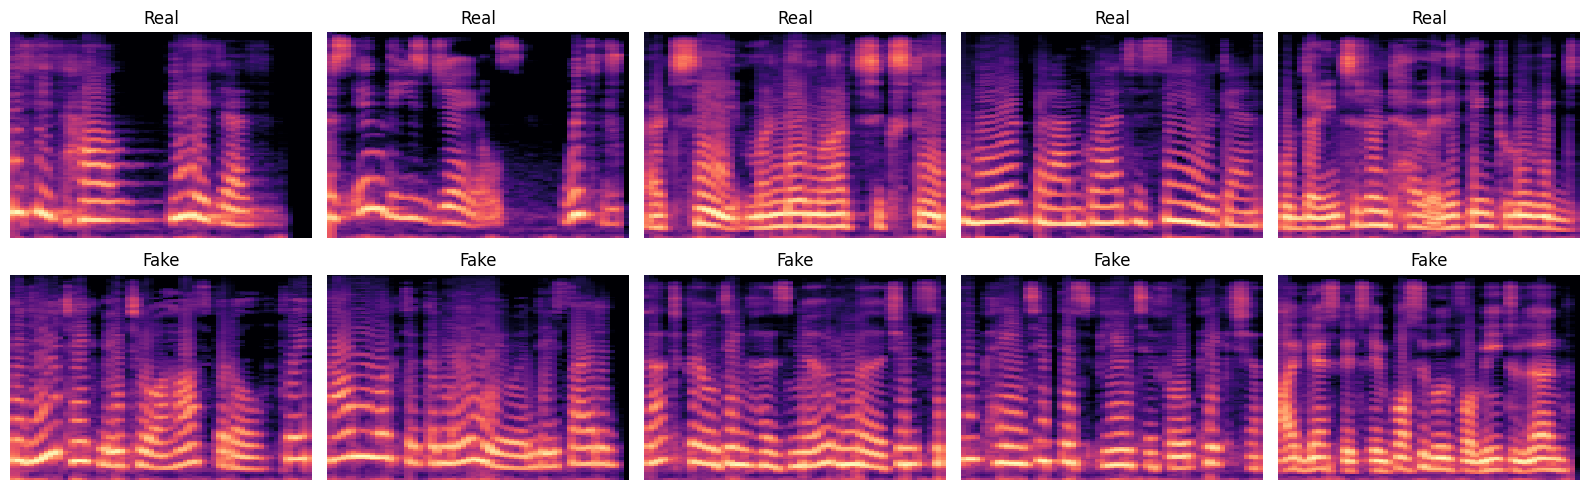

In [44]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(16,5))

for i, spec in enumerate(mel_specs):

    plt.subplot(2,5,i+1)  # 2 rows, 5 columns

    librosa.display.specshow(spec, x_axis="time", y_axis="mel")

    plt.title("Real" if labels[i]==1 else "Fake")
    plt.axis("off")

plt.tight_layout()
plt.show()

Lave spectrogrammer for hele training-datasættet

Training spectrograms

In [45]:
mel_specs_train = []
labels_train = []

# Real audio
for i, fp in enumerate(train_real):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(1)

    if (i+1) % 500 == 0:
        print("Processed train real:", i+1)

# Fake audio
for i, fp in enumerate(train_fake):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(0)

    if (i+1) % 500 == 0:
        print("Processed train fake:", i+1)

print("Total train spectrograms:", len(mel_specs_train))

Processed train real: 500
Processed train real: 1000
Processed train real: 1500
Processed train real: 2000
Processed train real: 2500
Processed train real: 3000
Processed train real: 3500
Processed train real: 4000
Processed train real: 4500
Processed train real: 5000
Processed train fake: 500
Processed train fake: 1000
Processed train fake: 1500
Processed train fake: 2000
Processed train fake: 2500
Processed train fake: 3000
Processed train fake: 3500
Processed train fake: 4000
Processed train fake: 4500
Processed train fake: 5000
Total train spectrograms: 10208


Validation spectrograms

In [46]:
mel_specs_val = []
labels_val = []

for fp in val_real:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(1)

for fp in val_fake:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(0)

print("Total validation spectrograms:", len(mel_specs_val))

Total validation spectrograms: 2244


Test spectrograms

In [47]:
mel_specs_test = []
labels_test = []

for fp in test_real:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(1)

for fp in test_fake:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(0)

print("Total test spectrograms:", len(mel_specs_test))

Total test spectrograms: 816


Konverter til arrays

* X = spectrogram billeder

* y = labels

In [52]:
X_train = np.array(mel_specs_train)[..., np.newaxis]
y_train = np.array(labels_train)

X_val = np.array(mel_specs_val)[..., np.newaxis]
y_val = np.array(labels_val)

X_test = np.array(mel_specs_test)[..., np.newaxis]
y_test = np.array(labels_test)

# Scale spectrograms from [-80, 0] → [0, 1]
X_train = (X_train + 80) / 80
X_val   = (X_val + 80) / 80
X_test  = (X_test + 80) / 80

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(10208, 128, 63, 1)
(2244, 128, 63, 1)
(816, 128, 63, 1)


In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models

baseline_cnn = models.Sequential([

    layers.Input(shape=(128, 63, 1)),

    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

history = baseline_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 61, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 30, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6720)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │       107,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 45s 136ms/step - accuracy: 0.6872 - loss: 0.5645 - val_accuracy: 0.8819 - val_loss: 0.3223
Epoch 2/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.8679 - loss: 0.3126 - val_accuracy: 0.9158 - val_loss: 0.2365
Epoch 3/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.9151 - loss: 0.2174 - val_accuracy: 0.9372 - val_loss: 0.1796
Epoch 4/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.9379 - loss: 0.1573 - val_accuracy: 0.9434 - val_loss: 0.1532
Epoch 5/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9553 - loss: 0.1306 - val_accuracy: 0.9345 - val_loss: 0.1663


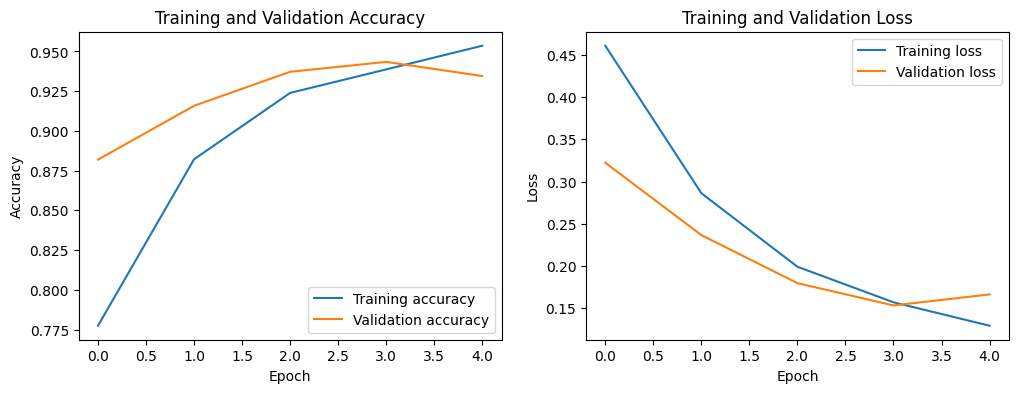

In [54]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Koderne nedenunder tester at alt er fint

In [55]:
set(train_real).intersection(set(val_real))
set(train_fake).intersection(set(val_fake))

set()

In [56]:
print("Train real:", len(train_real))
print("Train fake:", len(train_fake))

print("Validation real:", len(val_real))
print("Validation fake:", len(val_fake))

Train real: 5104
Train fake: 5104
Validation real: 1101
Validation fake: 1143


In [57]:
print(np.std(X_train))

0.21317407


Lave confusion matrix på validation

71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step


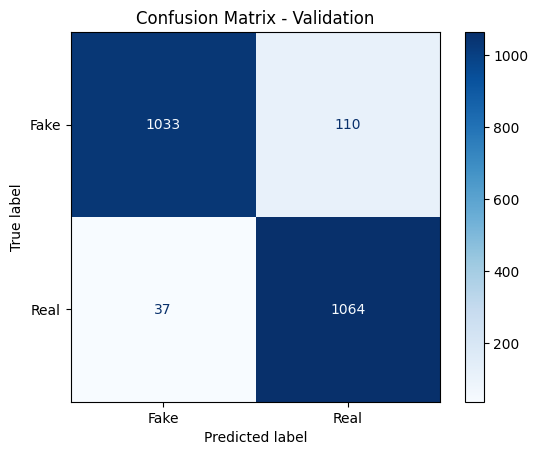

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation
y_prob_val = baseline_cnn.predict(X_val)
y_pred_val = (y_prob_val > 0.5).astype(int)

cm_val = confusion_matrix(y_val, y_pred_val)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Fake", "Real"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Validation")
plt.show()

Hvis man skal teste på test

In [61]:
test_loss, test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Test accuracy: 0.7977941036224365
Test loss: 0.4940009117126465


Lave confusion matrix på test

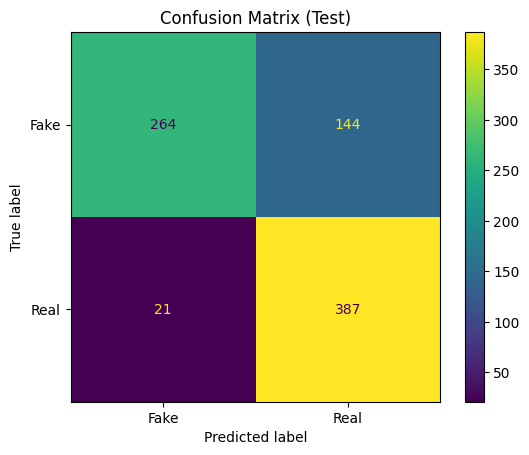

In [63]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_prob = baseline_cnn.predict(X_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Real"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

Din confusion matrix viser at modellen mister mange fakes (FN ~35%).
Så du kan skrive at baseline især har forbedringspotentiale på deepfake recall (det passer med jeres fokus).